# Chapter 04 Regression Modeling: rendered figures

Executed preview for browsing on GitHub (static image output, since GitHub's notebook viewer cannot run the interactive JS the live book uses). The source of truth for regenerating the book's figures is `chapter-04-regression-modeling-plots.py`. Run that script directly, not this notebook, to update `_generated/`.

# Regression Modeling

Recall from Chapter 1 that payload size and checkout-API latency showed a strong positive
correlation, and that correlation alone could not say how much of the relationship was causal.

*Regression modeling* is the tool that goes one step further: instead of a single number
summarizing how two variables move together, it produces a formula that predicts one variable
from another, and a set of diagnostics that say how much to trust that formula.

This chapter works through eight questions that come up whenever a prediction needs to be backed
by more than intuition:

1. *How do I fit a line through the data, and what does "best" mean?*
   Ordinary least squares answers both, along with the assumptions that make the answer
   trustworthy.
2. *How uncertain is a prediction, and does that uncertainty shrink with more data?*
   Confidence intervals and prediction intervals answer two different versions of that
   question.
3. *What changes once more than one predictor, or a category instead of a number, joins the
   model?*
   Multiple regression, dummy encoding, and interaction terms turn one straight line into
   something that can represent a fleet of servers and a workload at once, and the variance
   inflation factor flags when two of those predictors have started saying the same thing.
4. *What happens when the outcome is a category instead of a number?*
   Logistic regression extends the same machinery to binary outcomes.
5. *Once a model predicts a category, how is it graded?*
   Accuracy, precision, and recall turn a fitted threshold into a scorecard.
6. *How do I know if a model is a good fit, and not just a complicated one?*
   R-squared, adjusted R-squared, AIC, and BIC each answer a version of that question.
7. *What does a coefficient mean, and when does a significant one not matter?*
   Statistical significance and practical significance are not the same thing.
8. *What happens when there are more predictors than the data can support?*
   Regularization techniques trade a small amount of bias for a model that generalizes.

In [1]:
import os
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats

In [2]:
from IPython.display import Image

pio_width, pio_height = 760, 440

def show(fig: go.Figure, height: int = pio_height) -> Image:
    """Render a Plotly figure as a static PNG for the notebook preview
    (the live book embeds the interactive HTML version instead)."""
    return Image(fig.to_image(format="png", width=pio_width, height=height, scale=1))

## Setup

Random seed and helper functions shared by every figure in this chapter.

In [3]:
RNG = np.random.default_rng(23)

`payload_latency_sample` is a helper used by the figures below.

In [4]:
def payload_latency_sample(n: int, noise_sd: float, seed_offset: int = 0):
    rng = np.random.default_rng(23 + seed_offset)
    payload_kb = rng.uniform(2, 20, size=n)
    latency_ms = 25 + 9 * payload_kb + rng.normal(0, noise_sd, size=n)
    return payload_kb, latency_ms

`multi_predictor_latency_sample` is a helper used by the figures below.

In [5]:
def multi_predictor_latency_sample(n: int, seed_offset: int = 0):
    """Latency driven by payload size, concurrent load, and deployment region.

    Concurrent load is deliberately correlated with payload size (larger
    payloads tend to arrive during high-load batch windows), so a
    payload-only model absorbs part of load's effect. Region shifts the
    intercept: us-east is the reference level, us-west adds 9 ms, eu-west
    adds 17 ms, standing in for hardware or network differences across a
    fleet. The true payload effect (9 ms/KB) matches payload_latency_sample
    above on purpose, so the two sections can be read side by side.
    """
    rng = np.random.default_rng(23 + seed_offset)
    payload_kb = rng.uniform(2, 20, size=n)
    concurrent_load = 20 + 3.0 * payload_kb + rng.normal(0, 12, size=n)
    concurrent_load = np.clip(concurrent_load, 5, 95)
    region = rng.choice(["us-east", "us-west", "eu-west"], size=n, p=[0.5, 0.3, 0.2])
    shift_map = {"us-east": 0.0, "us-west": 9.0, "eu-west": 17.0}
    region_shift = np.array([shift_map[r] for r in region])
    latency_ms = 25 + 9.0 * payload_kb + 0.35 * concurrent_load + region_shift + rng.normal(0, 12, size=n)
    return payload_kb, concurrent_load, region, latency_ms

`fit_ols` is a helper used by the figures below.

In [6]:
def fit_ols(X: np.ndarray, y: np.ndarray) -> np.ndarray:
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    return beta

`compute_vif` is a helper used by the figures below.

In [7]:
def compute_vif(predictors: dict) -> dict:
    """Regress each predictor on every other predictor and return 1/(1-R^2)
    for each, the variance inflation factor. Hand-rolled rather than
    imported, matching this file's existing practice of computing its own
    small numerical methods (see soft_threshold and ridge_closed_form below)
    instead of reaching for a modeling library.
    """
    names = list(predictors.keys())
    X = np.column_stack([predictors[k] for k in names])
    n, p = X.shape
    vifs = {}
    for j, name in enumerate(names):
        y_j = X[:, j]
        other_cols = [k for k in range(p) if k != j]
        X_others = np.column_stack([np.ones(n)] + [X[:, k] for k in other_cols])
        beta = fit_ols(X_others, y_j)
        y_hat = X_others @ beta
        ss_res = np.sum((y_j - y_hat) ** 2)
        ss_tot = np.sum((y_j - y_j.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot
        vifs[name] = 1.0 / (1.0 - r2) if r2 < 0.9999 else float("inf")
    return vifs

`endpoint_latency_sample` is a helper used by the figures below.

In [8]:
def endpoint_latency_sample(n: int, seed_offset: int = 0):
    rng = np.random.default_rng(83 + seed_offset)
    endpoint_ids = [f"/api/v1/{name}" for name in [
        "checkout", "cart", "cart/items", "payments", "payments/verify", "shipping/rates",
        "shipping/label", "inventory/lookup", "inventory/reserve", "pricing/quote",
        "pricing/discount", "auth/token", "auth/refresh", "profile", "profile/address",
        "orders", "orders/status", "orders/cancel", "recommendations", "search",
        "search/suggest", "reviews", "reviews/submit", "wishlist", "notifications",
        "notifications/subscribe", "support/ticket", "fraud/score",
    ]]
    n_endpoints = len(endpoint_ids)
    # a handful of endpoints call slow external services (fraud checks, auth
    # refresh, notification delivery); most just touch local, cached data
    endpoint_latency_offset = rng.normal(0, 22, size=n_endpoints)
    endpoint_weights = rng.dirichlet(np.ones(n_endpoints) * 0.6)  # traffic is uneven across endpoints
    endpoint_idx = rng.choice(n_endpoints, size=n, p=endpoint_weights)
    payload_kb = rng.uniform(1, 15, size=n)
    latency_ms = 20 + 6 * payload_kb + endpoint_latency_offset[endpoint_idx] + rng.normal(0, 10, size=n)
    return endpoint_ids, endpoint_idx, payload_kb, latency_ms

`bin_by_residual` is a helper used by the figures below.

In [9]:
def bin_by_residual(endpoint_ids, endpoint_idx, resid, k_bins):
    n_endpoints = len(endpoint_ids)
    med_resid, counts = {}, {}
    for i in range(n_endpoints):
        mask = endpoint_idx == i
        if mask.sum() > 0:
            med_resid[endpoint_ids[i]] = float(np.median(resid[mask]))
            counts[endpoint_ids[i]] = int(mask.sum())
    sorted_eps = sorted(med_resid.keys(), key=lambda name: med_resid[name])
    total = sum(counts.values())
    target = total / k_bins
    bins = [[] for _ in range(k_bins)]
    cum, bin_i = 0, 0
    for ep in sorted_eps:
        bins[bin_i].append(ep)
        cum += counts[ep]
        if cum >= target * (bin_i + 1) and bin_i < k_bins - 1:
            bin_i += 1
    return sorted_eps, med_resid, counts, bins

`interaction_latency_sample` is a helper used by the figures below.

In [10]:
def interaction_latency_sample(n: int, slope_multiplier: float, seed_offset: int = 0):
    rng = np.random.default_rng(26 + seed_offset)
    concurrent_load = rng.uniform(10, 90, size=n)
    region = rng.choice(["us-east", "eu-west"], size=n, p=[0.55, 0.45])
    base_slope = 0.35
    load_slope = np.where(region == "us-east", base_slope, base_slope * slope_multiplier)
    latency_ms = 30 + load_slope * concurrent_load + rng.normal(0, 9, size=n)
    return concurrent_load, region, latency_ms

`vif_predictor_sample` is a helper used by the figures below.

In [11]:
def vif_predictor_sample(n: int, corr_strength: float, seed_offset: int = 0):
    rng = np.random.default_rng(23 + seed_offset)
    payload_kb = rng.uniform(2, 20, size=n)
    concurrent_load = rng.uniform(10, 90, size=n)
    noise = rng.normal(0, payload_kb.std(), size=n)
    response_kb = corr_strength * (payload_kb - payload_kb.mean()) * 3.0 + (1 - corr_strength) * noise
    response_kb = response_kb + 40
    return payload_kb, concurrent_load, response_kb

`soft_threshold` is a helper used by the figures below.

In [12]:
def soft_threshold(z: float, lam: float) -> float:
    return np.sign(z) * max(abs(z) - lam, 0.0)

`lasso_coordinate_descent` is a helper used by the figures below.

In [13]:
def lasso_coordinate_descent(X: np.ndarray, y: np.ndarray, lam: float, n_iter: int = 300) -> np.ndarray:
    n, p = X.shape
    beta = np.zeros(p)
    col_norms = np.sum(X ** 2, axis=0)
    for _ in range(n_iter):
        for j in range(p):
            residual = y - X @ beta + X[:, j] * beta[j]
            z = X[:, j] @ residual
            beta[j] = soft_threshold(z, lam) / col_norms[j] if col_norms[j] > 0 else 0.0
    return beta

`ridge_closed_form` is a helper used by the figures below.

In [14]:
def ridge_closed_form(X: np.ndarray, y: np.ndarray, lam: float) -> np.ndarray:
    p = X.shape[1]
    return np.linalg.solve(X.T @ X + lam * np.eye(p), X.T @ y)

`_short_n` is a helper used by the figures below.

In [15]:
def _short_n(n: int) -> str:
    if n >= 1_000_000:
        return f"{n / 1_000_000:g}M"
    if n >= 1_000:
        return f"{n / 1_000:g}k"
    return str(n)

## Ordinary least squares regression

Latency (ms) plotted against payload size (KB), with the fitted OLS line in red. Dragging the
noise slider higher scatters the dots further from the line: the fitted slope barely moves, but
R-squared falls sharply, since a noisier relationship leaves more of the variance unexplained
even while the slope itself stays close to correct.

In [16]:
def fig_ols_fit() -> go.Figure:
    noise_levels = [5, 15, 30, 50, 80]
    frames = []
    x_line = np.linspace(2, 20, 50)
    for noise in noise_levels:
        x, y = payload_latency_sample(150, noise)
        slope, intercept, r, p, se = stats.linregress(x, y)
        y_line = intercept + slope * x_line
        frames.append(
            go.Frame(
                name=str(noise),
                data=[
                    go.Scatter(x=x, y=y, mode="markers", marker=dict(color="#4C78A8", size=6, opacity=0.55)),
                    go.Scatter(x=x_line, y=y_line, mode="lines", line=dict(color="#E45756", width=3)),
                ],
                layout=go.Layout(annotations=[dict(
                    x=0.02, y=0.95, xref="paper", yref="paper", showarrow=False,
                    text=f"R-squared = {r**2:.2f}", font=dict(size=13, color="#333"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="An OLS fit of latency on payload size as noise grows",
        xaxis_title="payload size (KB)",
        yaxis_title="latency (ms)",
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "noise standard deviation (ms): "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

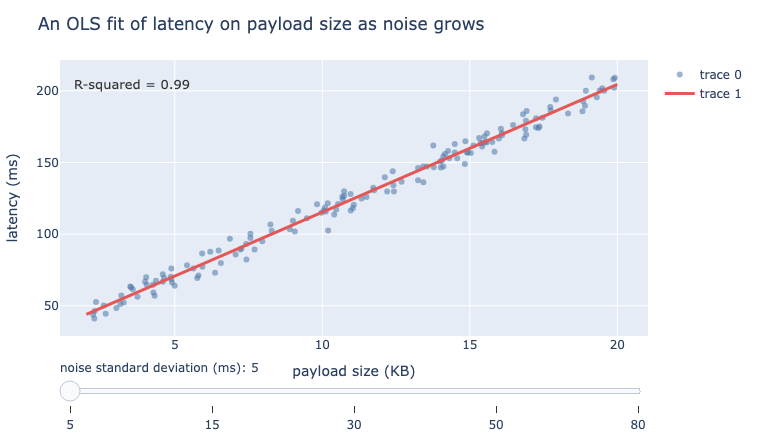

In [17]:
show(fig_ols_fit())

## Multiple regression: more than one predictor at a time

The estimated coefficient on payload size across three models fit to the same 300 requests, with
a dotted reference line at the 9 ms/KB effect this chapter's simulation was built to produce. A
payload-only model overstates that effect; adding concurrent load and then region pulls the
estimate back toward the reference line.

In [18]:
def fig_multiple_regression_coefficients() -> go.Figure:
    n = 300
    payload, load, region, latency = multi_predictor_latency_sample(n)
    is_us_west = (region == "us-west").astype(float)
    is_eu_west = (region == "eu-west").astype(float)

    steps = [
        ("payload only", np.column_stack([np.ones(n), payload]), [True, False, False, False]),
        ("+ concurrent load", np.column_stack([np.ones(n), payload, load]), [True, True, False, False]),
        ("+ region (dummies)", np.column_stack([np.ones(n), payload, load, is_us_west, is_eu_west]),
         [True, True, True, True]),
    ]
    predictor_names = ["payload size", "concurrent load", "region: us-west", "region: eu-west"]

    frames = []
    for label, X, included in steps:
        beta = fit_ols(X, latency)
        # beta[0] is the intercept; pad the remaining predictor slots with 0
        # so every frame plots the same four bars (a fixed x-axis, per this
        # book's own documented gotcha about animating categorical axes),
        # coloring a predictor not yet in the model gray instead of dropping
        # its bar.
        values = [0.0, 0.0, 0.0, 0.0]
        for i, is_in in enumerate(included):
            if is_in:
                values[i] = beta[i + 1]
        colors = ["#4C78A8" if is_in else "#D9D9D9" for is_in in included]
        frames.append(
            go.Frame(
                name=label,
                data=[go.Bar(x=predictor_names, y=values, marker_color=colors)],
                layout=go.Layout(annotations=[dict(
                    x=0.02, y=0.95, xref="paper", yref="paper", showarrow=False,
                    text=f"payload coefficient = {values[0]:.2f} ms/KB (true effect: 9.00)",
                    font=dict(size=13, color="#333"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="Adding predictors moves the payload coefficient toward its true effect",
        yaxis_title="estimated coefficient (ms)",
        shapes=[dict(type="line", x0=-0.5, x1=3.5, y0=9.0, y1=9.0, xref="x", yref="y",
                     line=dict(color="#999", width=1, dash="dot"))],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "model: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

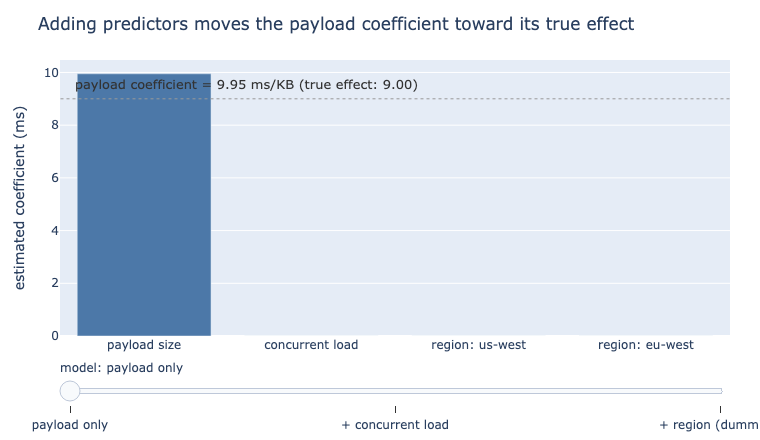

In [19]:
show(fig_multiple_regression_coefficients())

## Categorical predictors and dummy encoding

Gray bars show each region's raw average latency; blue bars show what the full model from the
section above predicts for that region once payload size and concurrent load are held at their
sample averages. The two views mostly agree for eu-west but diverge for us-west, where the raw
gap overstates region's own contribution.

In [20]:
def fig_region_dummy_effect() -> go.Figure:
    n = 300
    payload, load, region, latency = multi_predictor_latency_sample(n)
    is_us_west = (region == "us-west").astype(float)
    is_eu_west = (region == "eu-west").astype(float)
    X = np.column_stack([np.ones(n), payload, load, is_us_west, is_eu_west])
    beta = fit_ols(X, latency)

    regions = ["us-east", "us-west", "eu-west"]
    raw_means = [latency[region == r].mean() for r in regions]
    # adjusted mean: hold payload and load at their overall averages and read
    # off each region's dummy coefficient (0 for us-east, the reference level)
    payload_bar, load_bar = payload.mean(), load.mean()
    dummy_at_avg = [
        beta[0] + beta[1] * payload_bar + beta[2] * load_bar,
        beta[0] + beta[1] * payload_bar + beta[2] * load_bar + beta[3],
        beta[0] + beta[1] * payload_bar + beta[2] * load_bar + beta[4],
    ]

    fig = go.Figure(data=[
        go.Bar(x=regions, y=raw_means, name="raw group mean latency", marker_color="#B0B0B0"),
        go.Bar(x=regions, y=dummy_at_avg, name="model estimate at average payload and load",
               marker_color="#4C78A8"),
    ])
    fig.update_layout(
        barmode="group",
        title="A region's raw latency gap and its dummy-coefficient estimate need not agree",
        yaxis_title="latency (ms)",
        legend=dict(orientation="h", y=-0.2),
        margin=dict(t=60, l=60, r=30, b=70),
    )
    return fig

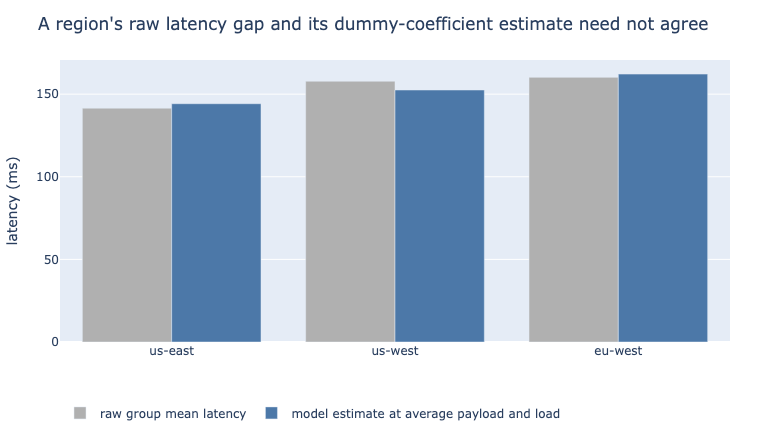

In [21]:
show(fig_region_dummy_effect())

## Binning high-cardinality categorical predictors by residual

Endpoints sorted left to right by their median residual from a payload-only model, colored by the
bin they fall into. Slide the bin count and the same sorted bars regroup into more or fewer
color-coded clusters, without changing any endpoint's underlying position.

In [22]:
def fig_endpoint_residual_binning() -> go.Figure:
    endpoint_ids, endpoint_idx, payload_kb, latency_ms = endpoint_latency_sample(350)
    n = len(payload_kb)
    X_control = np.column_stack([np.ones(n), payload_kb])
    beta_control = fit_ols(X_control, latency_ms)
    resid = latency_ms - X_control @ beta_control

    bin_counts = [2, 3, 4, 5, 6]
    palette = ["#4C78A8", "#E45756", "#54A24B", "#F58518", "#B279A2", "#72B7B2"]

    frames = []
    for k in bin_counts:
        sorted_eps, med_resid, counts, bins = bin_by_residual(endpoint_ids, endpoint_idx, resid, k)
        bin_of = {ep: i for i, group in enumerate(bins) for ep in group}
        colors = [palette[bin_of[ep] % len(palette)] for ep in sorted_eps]
        y_vals = [med_resid[ep] for ep in sorted_eps]
        short_labels = [ep.replace("/api/v1/", "") for ep in sorted_eps]
        frames.append(
            go.Frame(
                name=str(k),
                data=[go.Bar(x=short_labels, y=y_vals, marker_color=colors)],
                layout=go.Layout(annotations=[dict(
                    x=0.02, y=0.95, xref="paper", yref="paper", showarrow=False,
                    text=f"{k} bins, sorted by each endpoint's median residual",
                    font=dict(size=12, color="#333"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="Sorting endpoints by residual before binning groups the slow ones together",
        yaxis_title="median residual after a payload-only model (ms)",
        xaxis=dict(tickangle=45, tickfont=dict(size=9)),
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "number of bins: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=140),
    )
    return fig

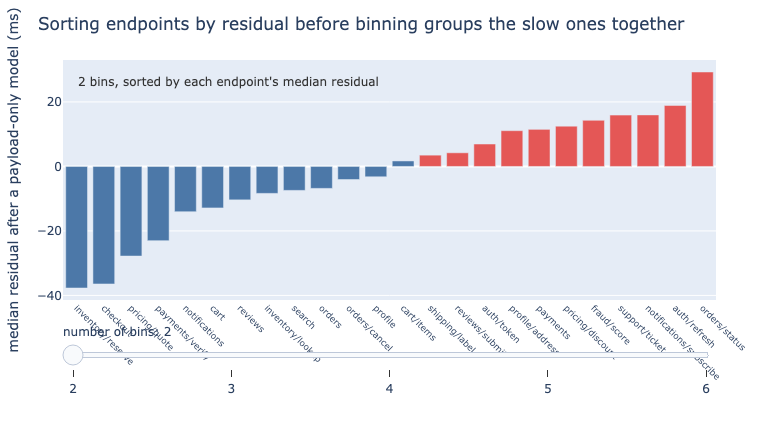

In [23]:
show(fig_endpoint_residual_binning())

## Interaction terms

Observed latency by concurrent load, split by region, with a dashed common-slope line ignoring
region entirely and two solid lines from a model that lets each region carry its own slope. As
the slider raises eu-west's load sensitivity, the dashed line increasingly misses both regions
while the two solid lines keep tracking each one.

In [24]:
def fig_interaction_slopes() -> go.Figure:
    multipliers = [1.0, 1.4375, 1.875, 2.3125, 2.75]
    load_grid = np.linspace(10, 90, 40)
    frames = []
    for mult in multipliers:
        load, region, latency = interaction_latency_sample(400, mult, seed_offset=3)
        is_eu = (region == "eu-west").astype(float)

        X_no_int = np.column_stack([np.ones(len(load)), load, is_eu])
        beta_no_int = fit_ols(X_no_int, latency)
        resid_no_int = latency - X_no_int @ beta_no_int
        sse_no_int = float(np.sum(resid_no_int ** 2))

        X_int = np.column_stack([np.ones(len(load)), load, is_eu, load * is_eu])
        beta_int = fit_ols(X_int, latency)
        resid_int = latency - X_int @ beta_int
        sse_int = float(np.sum(resid_int ** 2))

        us_east_line = beta_int[0] + beta_int[1] * load_grid
        eu_west_line = beta_int[0] + beta_int[2] + (beta_int[1] + beta_int[3]) * load_grid
        common_line = beta_no_int[0] + beta_no_int[1] * load_grid  # ignores region entirely

        frames.append(
            go.Frame(
                name=f"{mult:.2f}",
                data=[
                    go.Scatter(x=load[~is_eu.astype(bool)], y=latency[~is_eu.astype(bool)], mode="markers",
                               marker=dict(color="#4C78A8", size=5, opacity=0.45), name="us-east"),
                    go.Scatter(x=load[is_eu.astype(bool)], y=latency[is_eu.astype(bool)], mode="markers",
                               marker=dict(color="#E45756", size=5, opacity=0.45), name="eu-west"),
                    go.Scatter(x=load_grid, y=common_line, mode="lines",
                               line=dict(color="#999", width=2, dash="dash"), name="no interaction (one slope)"),
                    go.Scatter(x=load_grid, y=us_east_line, mode="lines",
                               line=dict(color="#4C78A8", width=3), name="us-east slope (interaction model)"),
                    go.Scatter(x=load_grid, y=eu_west_line, mode="lines",
                               line=dict(color="#E45756", width=3), name="eu-west slope (interaction model)"),
                ],
                layout=go.Layout(annotations=[dict(
                    x=0.02, y=0.97, xref="paper", yref="paper", showarrow=False, align="left",
                    text=(f"no-interaction SSE = {sse_no_int:,.0f}<br>"
                          f"interaction SSE = {sse_int:,.0f}<br>"
                          f"interaction coefficient = {beta_int[3]:.3f}"),
                    font=dict(size=12, color="#333"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="As the two regions' load sensitivity diverges, one common slope fits worse",
        xaxis_title="concurrent load (%)",
        yaxis_title="latency (ms)",
        legend=dict(orientation="h", y=-0.2),
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "eu-west load-slope multiplier: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=100),
    )
    return fig

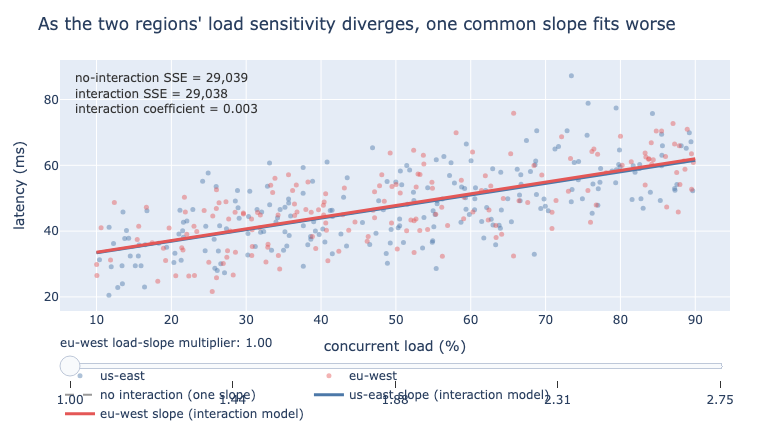

In [25]:
show(fig_interaction_slopes())

## Multicollinearity and the variance inflation factor

Variance inflation factor for three predictors on a log scale, as payload size and a stand-in
response-size field are pushed to move together more tightly. Dotted and dashed reference lines
mark the conventional VIF cutoffs of 5 and 10; concurrent load, unrelated to either one, barely
moves off the floor.

In [26]:
def fig_vif_bars() -> go.Figure:
    corr_strengths = [0.1, 0.4, 0.7, 0.85, 0.92]
    predictor_names = ["payload size", "concurrent load", "response size"]
    frames = []
    for cs in corr_strengths:
        payload_kb, load_kb, response_kb = vif_predictor_sample(250, cs, seed_offset=13)
        vifs = compute_vif({"payload size": payload_kb, "concurrent load": load_kb,
                             "response size": response_kb})
        r = float(np.corrcoef(payload_kb, response_kb)[0, 1])
        values = [vifs[name] for name in predictor_names]
        frames.append(
            go.Frame(
                name=f"{cs:.2f}",
                data=[go.Bar(x=predictor_names, y=values,
                              marker_color=["#E45756", "#4C78A8", "#E45756"])],
                layout=go.Layout(
                    yaxis=dict(type="log", range=[0, np.log10(max(values) * 1.5 + 1)]),
                    annotations=[dict(
                        x=0.02, y=0.95, xref="paper", yref="paper", showarrow=False,
                        text=f"corr(payload, response size) = {r:.3f}",
                        font=dict(size=13, color="#333"),
                    )],
                ),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="VIF stays near 1 for an unrelated predictor and explodes for a correlated pair",
        yaxis_title="variance inflation factor (log scale)",
        shapes=[
            dict(type="line", x0=-0.5, x1=2.5, y0=5, y1=5, xref="x", yref="y",
                 line=dict(color="#999", width=1, dash="dot")),
            dict(type="line", x0=-0.5, x1=2.5, y0=10, y1=10, xref="x", yref="y",
                 line=dict(color="#666", width=1, dash="dash")),
        ],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "correlation strength dial: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

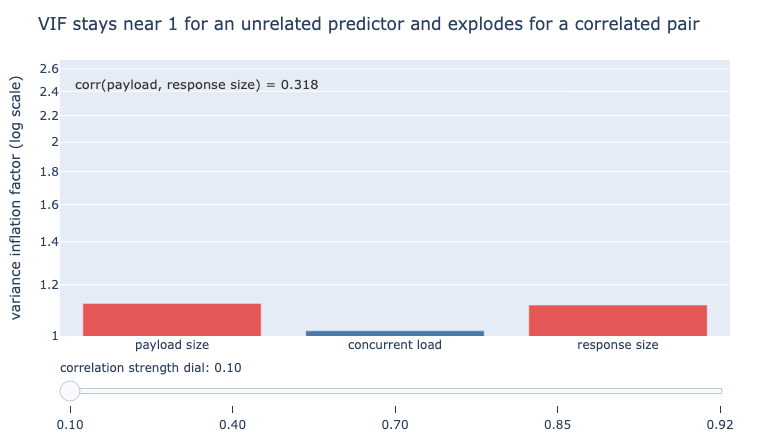

In [27]:
show(fig_vif_bars())

## Confidence intervals and prediction intervals

Latency (ms) against payload size (KB): the confidence band (red) narrows steadily as sample
size grows, since a larger sample pins down the mean more precisely. The prediction band (blue)
barely narrows at all, because no amount of data shrinks the irreducible variability of one new
request.

In [28]:
def fig_ci_vs_pi() -> go.Figure:
    sample_sizes = [10, 25, 50, 150, 500]
    x_grid = np.linspace(2, 20, 60)
    frames = []
    for n in sample_sizes:
        x, y = payload_latency_sample(n, 30)
        slope, intercept, r, p, se = stats.linregress(x, y)
        y_hat = intercept + slope * x
        resid = y - y_hat
        s = np.sqrt(np.sum(resid ** 2) / (n - 2))
        x_bar = x.mean()
        sxx = np.sum((x - x_bar) ** 2)
        t_val = stats.t.ppf(0.975, df=n - 2)

        y_line = intercept + slope * x_grid
        se_mean = s * np.sqrt(1 / n + (x_grid - x_bar) ** 2 / sxx)
        se_pred = s * np.sqrt(1 + 1 / n + (x_grid - x_bar) ** 2 / sxx)
        ci_lo, ci_hi = y_line - t_val * se_mean, y_line + t_val * se_mean
        pi_lo, pi_hi = y_line - t_val * se_pred, y_line + t_val * se_pred

        frames.append(
            go.Frame(
                name=str(n),
                data=[
                    go.Scatter(x=np.concatenate([x_grid, x_grid[::-1]]),
                               y=np.concatenate([pi_hi, pi_lo[::-1]]),
                               fill="toself", fillcolor="rgba(76,120,168,0.15)",
                               line=dict(width=0), name="95% prediction interval"),
                    go.Scatter(x=np.concatenate([x_grid, x_grid[::-1]]),
                               y=np.concatenate([ci_hi, ci_lo[::-1]]),
                               fill="toself", fillcolor="rgba(228,87,86,0.35)",
                               line=dict(width=0), name="95% confidence interval"),
                    go.Scatter(x=x_grid, y=y_line, mode="lines",
                               line=dict(color="#333", width=2), name="fitted line"),
                ],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="The confidence interval narrows with sample size; the prediction interval "
              "barely does",
        xaxis_title="payload size (KB)",
        yaxis_title="latency (ms)",
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "sample size (n): "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

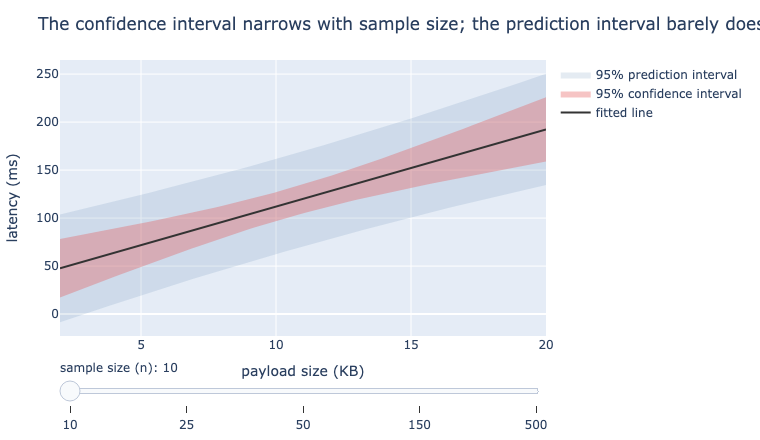

In [29]:
show(fig_ci_vs_pi())

## Logistic regression

P(timeout) against concurrent load: dots along the top and bottom edges are individual observed
requests (timed out or not), and the S-shaped curve is the fitted probability. A steeper curve
flips the service from healthy to overwhelmed over a narrower band of load; a shallower curve
spreads that same transition across a wider range.

In [30]:
def fig_logistic_timeout() -> go.Figure:
    steepness_options = [0.05, 0.15, 0.3, 0.6, 1.0]
    load = np.linspace(0, 100, 300)
    midpoint = 60
    rng = np.random.default_rng(31)
    load_obs = rng.uniform(0, 100, 200)
    frames = []
    for k in steepness_options:
        p = 1 / (1 + np.exp(-k * (load - midpoint)))
        p_obs = 1 / (1 + np.exp(-k * (load_obs - midpoint)))
        outcome_obs = (rng.uniform(size=len(load_obs)) < p_obs).astype(float)
        frames.append(
            go.Frame(
                name=f"{k:.2f}",
                data=[
                    go.Scatter(x=load_obs, y=outcome_obs, mode="markers",
                               marker=dict(color="#72B7B2", size=6, opacity=0.5),
                               name="observed timeout (0/1)"),
                    go.Scatter(x=load, y=p, mode="lines",
                               line=dict(color="#E45756", width=3),
                               name="P(timeout)"),
                ],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="Logistic regression: probability of a timeout as concurrent load rises",
        xaxis_title="concurrent load (%)",
        yaxis_title="P(timeout)",
        yaxis_range=[-0.05, 1.05],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "steepness of the logistic curve: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

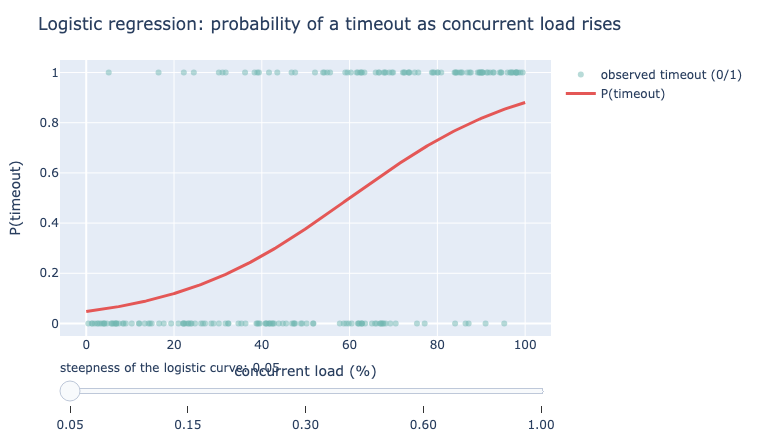

In [31]:
show(fig_logistic_timeout())

## Classification metrics: accuracy, precision, and recall

Counts of the four possible outcomes for 400 requests at a chosen threshold: correctly flagged
timeouts, wrongly flagged healthy requests, correctly cleared healthy requests, and missed
timeouts. Raising the threshold shrinks the false-positive bar and grows the false-negative bar,
while accuracy, shown in the corner, barely moves.

In [32]:
def fig_confusion_threshold() -> go.Figure:
    rng = np.random.default_rng(71)
    load = rng.uniform(0, 100, 400)
    k, midpoint = 0.12, 60
    p_fit = 1 / (1 + np.exp(-k * (load - midpoint)))
    observed_timeout = (rng.uniform(size=len(load)) < p_fit).astype(int)

    thresholds = [0.2, 0.35, 0.5, 0.65, 0.8]
    labels = ["true positive", "false positive", "true negative", "false negative"]
    colors = ["#4C78A8", "#E45756", "#72B7B2", "#F58518"]
    frames = []
    for t in thresholds:
        predicted_timeout = (p_fit >= t).astype(int)
        tp = int(np.sum((predicted_timeout == 1) & (observed_timeout == 1)))
        fp = int(np.sum((predicted_timeout == 1) & (observed_timeout == 0)))
        tn = int(np.sum((predicted_timeout == 0) & (observed_timeout == 0)))
        fn = int(np.sum((predicted_timeout == 0) & (observed_timeout == 1)))
        accuracy = (tp + tn) / len(observed_timeout)
        precision = tp / (tp + fp) if (tp + fp) else float("nan")
        recall = tp / (tp + fn) if (tp + fn) else float("nan")

        frames.append(
            go.Frame(
                name=f"{t:.2f}",
                data=[go.Bar(x=labels, y=[tp, fp, tn, fn], marker_color=colors)],
                layout=go.Layout(annotations=[dict(
                    x=0.98, y=0.95, xref="paper", yref="paper", showarrow=False, align="right",
                    text=(f"accuracy = {accuracy:.2f}<br>precision = {precision:.2f}<br>"
                          f"recall = {recall:.2f}"),
                    font=dict(size=13, color="#333"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="Raising the timeout-prediction threshold trades recall for precision",
        yaxis_title="count of requests",
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "predict-timeout threshold: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

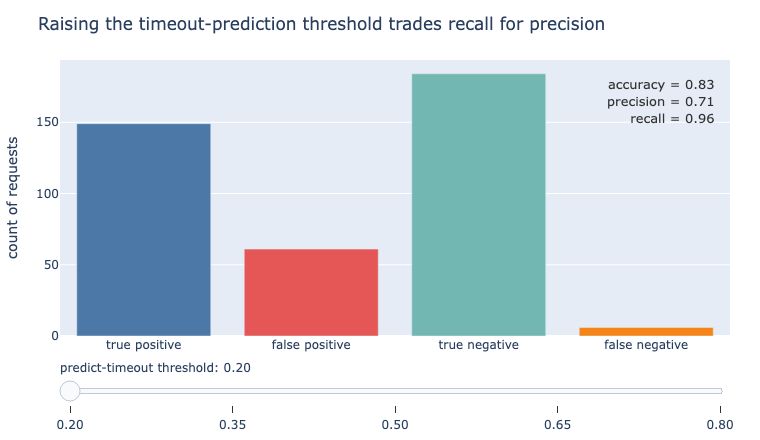

In [33]:
show(fig_confusion_threshold())

## Measuring fit: R-squared, adjusted R-squared, AIC, and BIC

Value (0 to 1) against the number of random noise predictors added to the model. R-squared
(blue) always rises as predictors are added, even useless ones. Adjusted R-squared (red)
penalizes that added complexity, flattening and then declining once the noise predictors stop
paying for themselves.

In [34]:
def fig_r2_vs_adjusted() -> go.Figure:
    n = 40
    x, y = payload_latency_sample(n, 30, seed_offset=5)
    rng = np.random.default_rng(41)
    noise_predictors = rng.normal(size=(n, 20))

    max_k = list(range(0, 21))
    frames = []
    r2_series, adj_r2_series = [], []
    for k in max_k:
        X = np.column_stack([np.ones(n), x, noise_predictors[:, :k]])
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        y_hat = X @ beta
        ss_res = np.sum((y - y_hat) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot
        p = X.shape[1] - 1
        adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
        r2_series.append(r2)
        adj_r2_series.append(adj_r2)
        frames.append(
            go.Frame(
                name=str(k),
                data=[
                    go.Scatter(x=max_k[: k + 1], y=r2_series, mode="lines+markers",
                               line=dict(color="#4C78A8", width=3), name="R-squared"),
                    go.Scatter(x=max_k[: k + 1], y=adj_r2_series, mode="lines+markers",
                               line=dict(color="#E45756", width=3), name="Adjusted R-squared"),
                ],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="R-squared always rises as predictors are added; adjusted R-squared does not",
        xaxis_title="number of random noise predictors added to the model",
        yaxis_title="value",
        xaxis_range=[0, 20],
        yaxis_range=[0, 1],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "noise predictors added: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

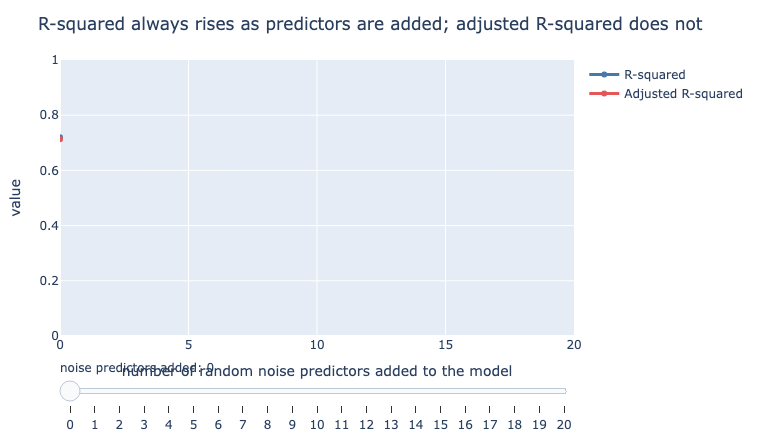

In [35]:
show(fig_r2_vs_adjusted())

## Measuring fit: R-squared, adjusted R-squared, AIC, and BIC

Both AIC and BIC reward adding region, which carries a measurable effect, but BIC penalizes the
noise predictor, time of day, more heavily than AIC does, and that gap widens as the sample size
grows.

In [36]:
def fig_aic_bic() -> go.Figure:
    rng = np.random.default_rng(61)
    n_max = 400
    payload = rng.uniform(2, 20, n_max)
    region = rng.normal(size=n_max)
    time_of_day = rng.normal(size=n_max)
    true_latency = 25 + 9 * payload + 6 * region + rng.normal(0, 20, n_max)

    model_specs = [
        ("payload only", [payload]),
        ("payload + region", [payload, region]),
        ("payload + region + time of day", [payload, region, time_of_day]),
    ]

    sample_sizes = [30, 60, 120, 250, 400]
    frames = []
    for n in sample_sizes:
        aic_vals, bic_vals = [], []
        y = true_latency[:n]
        for _, predictors in model_specs:
            X = np.column_stack([np.ones(n)] + [p[:n] for p in predictors])
            beta, *_ = np.linalg.lstsq(X, y, rcond=None)
            resid = y - X @ beta
            k = X.shape[1]
            sigma2 = np.sum(resid ** 2) / n
            log_lik = -0.5 * n * (np.log(2 * np.pi * sigma2) + 1)
            aic_vals.append(-2 * log_lik + 2 * k)
            bic_vals.append(-2 * log_lik + k * np.log(n))

        labels = [name for name, _ in model_specs]
        frames.append(
            go.Frame(
                name=str(n),
                data=[
                    go.Bar(x=labels, y=aic_vals, name="AIC", marker_color="#4C78A8"),
                    go.Bar(x=labels, y=bic_vals, name="BIC", marker_color="#E45756"),
                ],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        barmode="group",
        title="AIC and BIC across three candidate models, as sample size grows",
        yaxis_title="information criterion (lower is better)",
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "sample size (n): "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

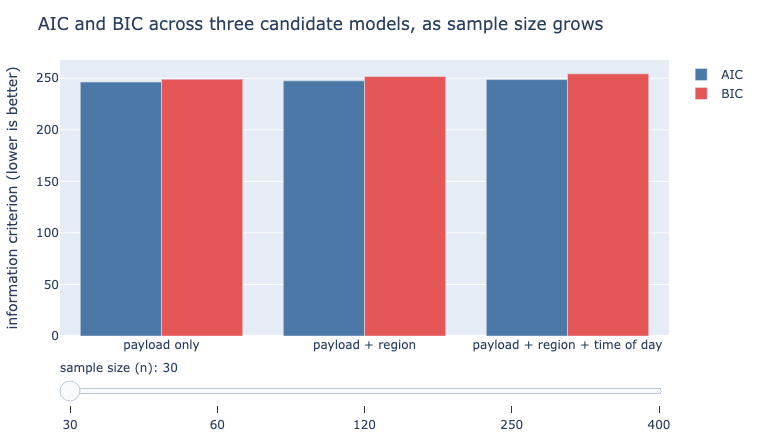

In [37]:
show(fig_aic_bic())

## Model interpretation: statistical significance versus practical significance

The estimated effect (0.1 ms) never moves. Only its 95% confidence interval does: wide and
straddling zero at small sample sizes, narrow and clear of zero once the sample is large enough.
The marker turns red the moment the p-value crosses 0.05, at a sample size where 0.1 ms is still
too small to act on.

In [38]:
def fig_significance_vs_sample_size() -> go.Figure:
    true_effect = 0.1  # ms: the same tiny, practically negligible effect used in the text
    noise_sd = 30.0    # ms: same latency noise scale used throughout this chapter's figures

    sample_sizes = [1_000, 10_000, 100_000, 500_000, 2_000_000, 10_000_000]
    frames = []
    for n in sample_sizes:
        # The point estimate is held at the true effect on purpose, rather than redrawn
        # per frame: the story here is that the effect size itself never moves. Only the
        # standard error, se = noise_sd / sqrt(n), shrinks as n grows, which is what pulls
        # the confidence interval away from zero and the p-value below 0.05.
        se = noise_sd / np.sqrt(n)
        z = true_effect / se
        p_value = 2 * (1 - stats.norm.cdf(abs(z)))
        ci_lo, ci_hi = true_effect - 1.96 * se, true_effect + 1.96 * se
        significant = p_value < 0.05

        frames.append(
            go.Frame(
                name=str(n),
                data=[
                    go.Scatter(
                        x=[true_effect], y=[0], mode="markers",
                        marker=dict(size=18, color="#E45756" if significant else "#4C78A8"),
                        error_x=dict(type="data", array=[1.96 * se], visible=True,
                                     thickness=3, width=10,
                                     color="#E45756" if significant else "#4C78A8"),
                        name="estimated effect",
                    ),
                ],
                layout=go.Layout(annotations=[dict(
                    x=0.02, y=0.85, xref="paper", yref="paper", showarrow=False, align="left",
                    text=(f"n = {n:,}<br>"
                          f"estimated effect = {true_effect:.3f} ms<br>"
                          f"95% CI = [{ci_lo:.3f}, {ci_hi:.3f}]<br>"
                          f"p-value = {p_value:.4g}<br>"
                          + ("statistically significant" if significant
                             else "not statistically significant") + " at alpha = 0.05"),
                    font=dict(size=13, color="#333"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="A fixed 0.1 ms effect crosses statistical significance as sample size grows",
        xaxis_title="estimated effect on latency (ms)",
        xaxis_range=[-2, 2.3],
        yaxis=dict(visible=False, range=[-1, 1]),
        shapes=[dict(type="line", x0=0, x1=0, y0=-1, y1=1,
                     line=dict(color="#999", width=1, dash="dot"))],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "sample size (n): "},
            "steps": [
                {"label": _short_n(int(f.name)), "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

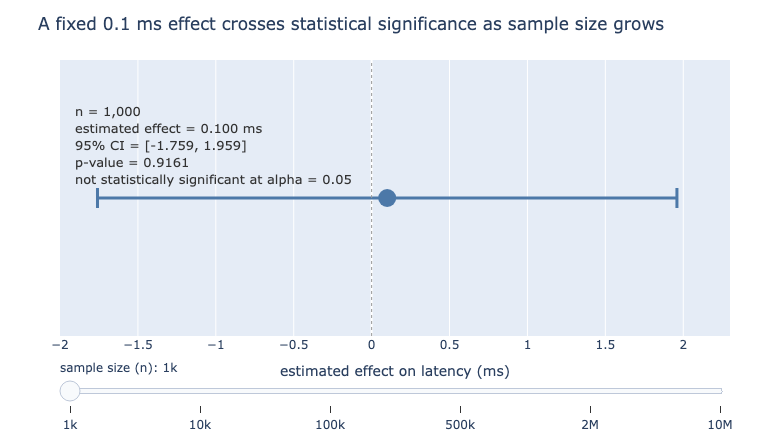

In [39]:
show(fig_significance_vs_sample_size())

## Regularization: Lasso, Ridge, and Elastic Net

Coefficient value for each predictor, comparing Lasso (red) against Ridge (blue) as the
regularization strength grows. As regularization strengthens, Lasso zeroes out the noise
predictor and one of the two correlated region indicators, while Ridge only shrinks every
coefficient toward zero without eliminating any of them.

In [40]:
def fig_regularization_paths() -> go.Figure:
    n = 60
    rng = np.random.default_rng(51)
    payload = rng.uniform(2, 20, n)
    region_a = rng.normal(size=n) * 0.5 + payload * 0.3   # correlated with payload
    region_b = rng.normal(size=n) * 0.5 + payload * 0.25  # also correlated with payload
    time_of_day = rng.normal(size=n)                       # unrelated noise feature
    endpoint_flag = rng.normal(size=n) * 0.3 + payload * 0.1

    X_raw = np.column_stack([payload, region_a, region_b, time_of_day, endpoint_flag])
    X = (X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)
    true_beta = np.array([9.0, 3.0, 2.5, 0.0, 1.0])
    y = X_raw @ true_beta + rng.normal(0, 15, size=n)
    y = y - y.mean()

    # lambdas run from 0.01 to 40 rather than 60: at the old top end (60) the Lasso
    # threshold, scaled to match this standardized design matrix, zeroed out every
    # predictor except payload size, including region A, so the chart no longer showed
    # the "keeps one of the two correlated region indicators" behavior the caption
    # describes. The 10x scale factor below (lam * 10) brings Lasso's zeroing point into
    # the same lambda range where Ridge's shrinkage is also visible, so both traces move
    # meaningfully across the same slider instead of Lasso barely changing at all.
    lambdas = [0.01, 0.5, 2, 8, 25, 40]
    feature_names = ["payload size", "region A", "region B", "time of day", "endpoint"]

    frames = []
    for lam in lambdas:
        lasso_beta = lasso_coordinate_descent(X, y, lam=lam * 10)
        ridge_beta = ridge_closed_form(X, y, lam=lam)
        frames.append(
            go.Frame(
                name=f"{lam:g}",
                data=[
                    go.Bar(x=feature_names, y=lasso_beta, name="Lasso", marker_color="#E45756"),
                    go.Bar(x=feature_names, y=ridge_beta, name="Ridge", marker_color="#4C78A8"),
                ],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        barmode="group",
        title="Lasso drives correlated and irrelevant coefficients to zero; "
              "Ridge only shrinks them",
        yaxis_title="coefficient value",
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "regularization strength (lambda): "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=70, l=60, r=30, b=50),
    )
    return fig

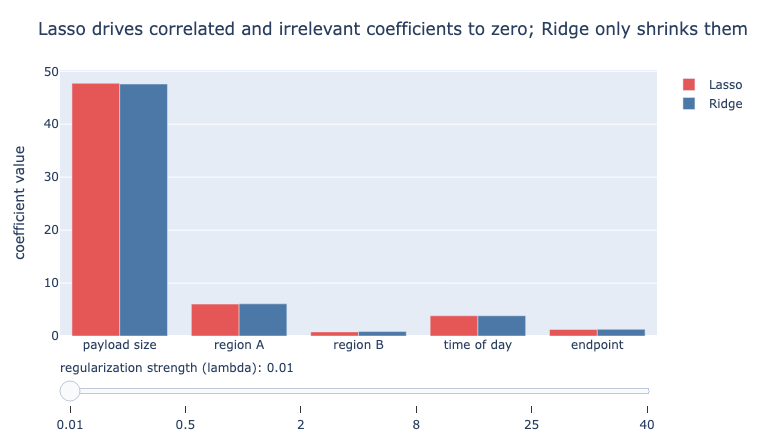

In [41]:
show(fig_regularization_paths())

## A Bayesian perspective

As the prior variance shrinks, equivalent to $\lambda$ growing, the fitted line on the left
visibly flattens away from the fixed, dashed OLS reference, while the posterior on the right
narrows and its center moves toward zero, tracing the same shrinkage Ridge regression's
penalty term produces.

In [42]:
def fig_bayesian_ridge() -> go.Figure:
    # Two panels driven by the same slider: the left panel grounds the abstract
    # posterior in something concrete (the fitted line visibly flattening toward
    # the dashed, never-changing OLS reference as the prior tightens), the right
    # panel keeps the posterior-density view for the uncertainty story the left
    # panel alone can't tell.
    #
    # Slider steps use method="restyle", not the frames/animate() pattern used
    # elsewhere in this book. animate() was tried first and confirmed broken
    # here: inspecting the live page's Plotly data model after moving the
    # slider showed trace 2 (the left-panel fit line) HAD received the correct
    # new y-values internally (decoded its typed-array binary buffer to
    # confirm), but the on-screen SVG never redrew, even with
    # frame.redraw=True. Traces 3-4 on the second subplot's axes (xaxis2/
    # yaxis2) animated correctly the whole time; only the trace sharing the
    # figure's default xaxis/yaxis with a two-column make_subplots layout was
    # affected. restyle() does not break this way.
    x, y = payload_latency_sample(150, 30, seed_offset=9)
    x_c = x - x.mean()
    y_c = y - y.mean()
    slope, intercept, r, p, se = stats.linregress(x, y)
    resid = y_c - slope * x_c
    sigma2 = np.sum(resid ** 2) / (len(x) - 2)
    S = np.sum(x_c ** 2)
    b = np.sum(x_c * y_c)

    x_line = np.linspace(x.min(), x.max(), 50)
    ols_y_line = intercept + slope * x_line

    prior_variances = [1e6, 50, 10, 3, 1, 0.3]
    beta_grid = np.linspace(-2, 16, 400)

    def stats_at(tau2):
        precision = S / sigma2 + 1 / tau2
        post_mean = (b / sigma2) / precision
        post_sd = np.sqrt(1 / precision)
        implied_lambda = sigma2 / tau2
        return post_mean, post_sd, implied_lambda

    post_mean0, post_sd0, lambda0 = stats_at(prior_variances[0])
    density0 = stats.norm.pdf(beta_grid, loc=post_mean0, scale=post_sd0)
    fit_y_line0 = y.mean() + post_mean0 * (x_line - x.mean())
    stat_text0 = (f"posterior mean = {post_mean0:.2f}<br>posterior sd = {post_sd0:.2f}"
                  f"<br>implied Ridge λ = {lambda0:.2f}")

    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=("Fitted line on the data", "Posterior over the slope"),
        horizontal_spacing=0.1,
    )
    fig.add_trace(go.Scatter(x=x, y=y, mode="markers",
                              marker=dict(color="#999", size=5, opacity=0.5),
                              name="data", showlegend=False), row=1, col=1)
    fig.add_trace(go.Scatter(x=x_line, y=ols_y_line, mode="lines",
                              line=dict(color="#999", width=2, dash="dash"),
                              name="OLS fit (no prior)"), row=1, col=1)
    fig.add_trace(go.Scatter(x=x_line, y=fit_y_line0, mode="lines",
                              line=dict(color="#4C78A8", width=3),
                              name="posterior-mean fit"), row=1, col=1)
    fig.add_trace(go.Scatter(x=beta_grid, y=density0, mode="lines",
                              line=dict(color="#4C78A8", width=3), fill="tozeroy",
                              fillcolor="rgba(76,120,168,0.2)", name="posterior",
                              showlegend=False), row=1, col=2)
    fig.add_trace(go.Scatter(x=[10.5], y=[0.85], mode="text", text=[stat_text0],
                              textposition="middle right", textfont=dict(size=12, color="#333"),
                              showlegend=False, hoverinfo="skip"), row=1, col=2)

    steps = []
    for tau2 in prior_variances:
        post_mean, post_sd, implied_lambda = stats_at(tau2)
        density = stats.norm.pdf(beta_grid, loc=post_mean, scale=post_sd)
        fit_y_line = y.mean() + post_mean * (x_line - x.mean())
        stat_text = (f"posterior mean = {post_mean:.2f}<br>posterior sd = {post_sd:.2f}"
                     f"<br>implied Ridge λ = {implied_lambda:.2f}")

        steps.append({
            "label": f"{tau2:g}",
            "method": "restyle",
            "args": [
                {
                    "x": [x_line.tolist(), beta_grid.tolist(), [10.5]],
                    "y": [fit_y_line.tolist(), density.tolist(), [0.85]],
                    "text": [None, None, [stat_text]],
                },
                [2, 3, 4],
            ],
        })

    fig.update_layout(
        title="A tighter Gaussian prior on the slope is Ridge regression: the fitted "
              "line flattens and the posterior narrows toward zero",
        legend=dict(orientation="h", y=-0.15, x=0.0),
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "prior variance on beta (tau-squared): "},
            # y and pad.t push the slider well clear of the x-axis title below it,
            # which otherwise renders in the same vertical band and overlaps the
            # slider's "currentvalue" caption text.
            "y": -0.35,
            "pad": {"t": 40},
            "steps": steps,
        }],
        margin=dict(t=90, l=60, r=30, b=150),
    )
    fig.update_xaxes(title_text="payload size (KB)", row=1, col=1)
    fig.update_yaxes(title_text="latency (ms)", row=1, col=1)
    fig.update_xaxes(title_text="coefficient on payload size (beta)", range=[-2, 16], row=1, col=2)
    fig.update_yaxes(title_text="posterior density", range=[0, 1.0], row=1, col=2)
    return fig

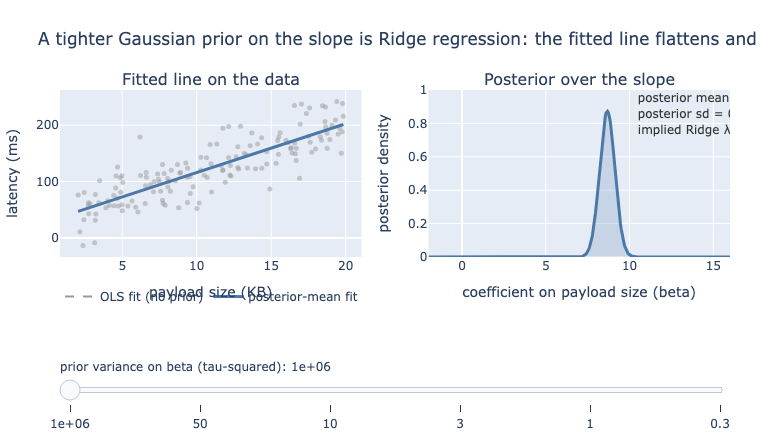

In [43]:
show(fig_bayesian_ridge())